In [ ]:
!pip install equinox optax jaxtyping matplotlib -q

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
from jaxtyping import Array, Float, Int, PRNGKeyArray
from typing import Optional
import matplotlib.pyplot as plt
import time

print(f"JAX version   : {jax.__version__}")
print(f"Equinox version: {eqx.__version__}")
print(f"Devices       : {jax.devices()}")

print("\n" + "="*60)
print("SECTION 1: eqx.Module basics")
print("="*60)

class Linear(eqx.Module):
    weight: Float[Array, "out in"]
    bias:   Float[Array, "out"]

    def __init__(self, in_size: int, out_size: int, *, key: PRNGKeyArray):
        wkey, bkey = jax.random.split(key)
        self.weight = jax.random.normal(wkey, (out_size, in_size)) * 0.1
        self.bias = jax.random.normal(bkey, (out_size,)) * 0.01

    def __call__(self, x: Float[Array, "in"]) -> Float[Array, "out"]:
        return self.weight @ x + self.bias


key = jax.random.PRNGKey(0)
lin = Linear(4, 2, key=key)

leaves, treedef = jax.tree_util.tree_flatten(lin)
print("Leaves shapes:", [l.shape for l in leaves])
print("Treedef:", treedef)

print("\n" + "="*60)
print("SECTION 2: Static fields")
print("="*60)

class Conv1dBlock(eqx.Module):
    conv:        eqx.nn.Conv1d
    norm:        eqx.nn.LayerNorm
    activation:  str = eqx.field(static=True)

    def __init__(self, channels: int, kernel: int, activation: str, *, key: PRNGKeyArray):
        self.conv       = eqx.nn.Conv1d(channels, channels, kernel, padding="same", key=key)
        self.norm       = eqx.nn.LayerNorm((channels,))
        self.activation = activation

    def __call__(self, x: Float[Array, "C L"]) -> Float[Array, "C L"]:
        x = self.conv(x)
        x = jax.vmap(self.norm)(x.T).T
        if self.activation == "relu":
            return jax.nn.relu(x)
        elif self.activation == "gelu":
            return jax.nn.gelu(x)
        return x


key, subkey = jax.random.split(key)
block = Conv1dBlock(8, 3, "gelu", key=subkey)
x_seq = jnp.ones((8, 16))
out = block(x_seq)
print(f"Conv1dBlock output shape: {out.shape}")

In [ ]:
print("\n" + "="*60)
print("SECTION 3: Filtered transforms")
print("="*60)

class MLP(eqx.Module):
    layers: list
    dropout: eqx.nn.Dropout

    def __init__(self, in_size, hidden, out_size, *, key: PRNGKeyArray):
        k1, k2, k3 = jax.random.split(key, 3)
        self.layers  = [
            eqx.nn.Linear(in_size, hidden, key=k1),
            eqx.nn.Linear(hidden,  hidden, key=k2),
            eqx.nn.Linear(hidden,  out_size, key=k3),
        ]
        self.dropout = eqx.nn.Dropout(p=0.1)

    def __call__(self, x: Float[Array, "in"], *, key: Optional[PRNGKeyArray] = None) -> Float[Array, "out"]:
        for layer in self.layers[:-1]:
            x = jax.nn.relu(layer(x))
            if key is not None:
                key, subkey = jax.random.split(key)
                x = self.dropout(x, key=subkey)
        return self.layers[-1](x)


key, mk = jax.random.split(key)
mlp = MLP(8, 32, 4, key=mk)

@eqx.filter_jit
def forward(model, x, *, key):
    return model(x, key=key)

x_in  = jnp.ones((8,))
key, fk = jax.random.split(key)
y_out = forward(mlp, x_in, key=fk)
print(f"MLP output: {y_out}")

@eqx.filter_jit
def loss_fn(model: MLP,
            x: Float[Array, "B in"],
            y: Float[Array, "B out"],
            key: PRNGKeyArray) -> Float[Array, ""]:
    keys  = jax.random.split(key, x.shape[0])
    preds = jax.vmap(model)(x)
    return jnp.mean((preds - y) ** 2)

grad_fn = eqx.filter_grad(loss_fn)

key, dk = jax.random.split(key)
X = jax.random.normal(dk, (16, 8))
Y = jax.random.normal(dk, (16, 4))
grads = grad_fn(mlp, X, Y, dk)
print(f"Grad of first layer weight: shape={grads.layers[0].weight.shape}, norm={jnp.linalg.norm(grads.layers[0].weight):.4f}")

In [ ]:
print("\n" + "="*60)
print("SECTION 4: PyTree manipulation")
print("="*60)

arrays, non_arrays = eqx.partition(mlp, eqx.is_array)
print("Non-array leaves (structure only):", jax.tree_util.tree_leaves(non_arrays))

trainable_filter = jax.tree_util.tree_map(
    lambda _: True, mlp
)
trainable_filter = eqx.tree_at(
    lambda m: (m.layers[0].weight, m.layers[0].bias),
    trainable_filter,
    replace=(False, False),
)
trainable, frozen = eqx.partition(mlp, trainable_filter)
print("Frozen params (first layer weight shape):", frozen.layers[0].weight.shape)
print("Trainable first-layer weight is sentinel:", trainable.layers[0].weight)

key, nk = jax.random.split(key)
new_weight = jax.random.normal(nk, mlp.layers[0].weight.shape)
mlp_updated = eqx.tree_at(lambda m: m.layers[0].weight, mlp, new_weight)
print("Updated first-layer weight norm:", jnp.linalg.norm(mlp_updated.layers[0].weight).item())

print("\n" + "="*60)
print("SECTION 5: Stateful layers — BatchNorm with inference mode")
print("="*60)

class BNModel(eqx.Module):
    linear1: eqx.nn.Linear
    bn:      eqx.nn.BatchNorm
    linear2: eqx.nn.Linear

    def __init__(self, in_f, hidden, out_f, *, key: PRNGKeyArray):
        k1, k2 = jax.random.split(key)
        self.linear1 = eqx.nn.Linear(in_f, hidden, key=k1)
        self.bn      = eqx.nn.BatchNorm(hidden, axis_name="batch")
        self.linear2 = eqx.nn.Linear(hidden, out_f, key=k2)

    def __call__(self, x, state, *, inference: bool = False):
        x, state = self.bn(jax.nn.relu(self.linear1(x)), state, inference=inference)
        return self.linear2(x), state


key, bk = jax.random.split(key)
bn_model, bn_state = eqx.nn.make_with_state(BNModel)(4, 16, 2, key=bk)

@eqx.filter_jit
def train_step_bn(model, state, x):
    def single(x):
        return model(x, state)
    outs, states = jax.vmap(single, axis_name="batch", out_axes=(0, None))(x)
    return outs, states

x_batch = jax.random.normal(key, (8, 4))
preds, bn_state = train_step_bn(bn_model, bn_state, x_batch)
print(f"BNModel output shape: {preds.shape}")

In [ ]:
print("\n" + "="*60)
print("SECTION 6: Full training loop (ResNet MLP on noisy sine)")
print("="*60)

class ResBlock(eqx.Module):
    fc1: eqx.nn.Linear
    fc2: eqx.nn.Linear
    proj: Optional[eqx.nn.Linear]

    def __init__(self, size: int, *, key: PRNGKeyArray):
        k1, k2 = jax.random.split(key)
        self.fc1  = eqx.nn.Linear(size, size, key=k1)
        self.fc2  = eqx.nn.Linear(size, size, key=k2)
        self.proj = None

    def __call__(self, x):
        residual = x
        x = jax.nn.gelu(self.fc1(x))
        x = self.fc2(x)
        return jax.nn.gelu(x + residual)


class ResNetMLP(eqx.Module):
    embed:   eqx.nn.Linear
    blocks:  list
    head:    eqx.nn.Linear

    def __init__(self, in_size, hidden, out_size, n_blocks, *, key: PRNGKeyArray):
        keys = jax.random.split(key, n_blocks + 2)
        self.embed  = eqx.nn.Linear(in_size, hidden, key=keys[0])
        self.blocks = [ResBlock(hidden, key=keys[i+1]) for i in range(n_blocks)]
        self.head   = eqx.nn.Linear(hidden, out_size, key=keys[-1])

    def __call__(self, x):
        x = jax.nn.gelu(self.embed(x))
        for block in self.blocks:
            x = block(x)
        return self.head(x)


def make_dataset(n: int, key: PRNGKeyArray):
    xk, nk = jax.random.split(key)
    x = jax.random.uniform(xk, (n, 1), minval=-1.0, maxval=1.0)
    y = jnp.sin(2 * jnp.pi * x) + 0.1 * jax.random.normal(nk, (n, 1))
    return x, y

key, dk = jax.random.split(key)
X_train, Y_train = make_dataset(2048, dk)
key, dk = jax.random.split(key)
X_val,   Y_val   = make_dataset(512,  dk)

key, mk = jax.random.split(key)
model = ResNetMLP(1, 64, 1, n_blocks=4, key=mk)

schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=3e-3,
    warmup_steps=200, decay_steps=2000
)
optimiser = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(schedule))
opt_state = optimiser.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def train_step(model, opt_state, x, y):
    def compute_loss(model, x, y):
        preds = jax.vmap(model)(x)
        return jnp.mean((preds - y) ** 2)

    loss, grads = eqx.filter_value_and_grad(compute_loss)(model, x, y)
    updates, opt_state_new = optimiser.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model_new = eqx.apply_updates(model, updates)
    return model_new, opt_state_new, loss


@eqx.filter_jit
def evaluate(model, x, y):
    preds = jax.vmap(model)(x)
    return jnp.mean((preds - y) ** 2)

JAX version   : 0.7.2
Equinox version: 0.13.6
Devices       : [CpuDevice(id=0)]

SECTION 1: eqx.Module basics
Leaves shapes: [(2, 4), (2,)]
Treedef: PyTreeDef(CustomNode(Linear[(Missing,)], [*, *]))

SECTION 2: Static fields
Conv1dBlock output shape: (8, 16)

SECTION 3: Filtered transforms
MLP output: [-0.09454373 -0.04626372  0.03485964  0.08805592]
Grad of first layer weight: shape=(32, 8), norm=0.1281

SECTION 4: PyTree manipulation
Non-array leaves (structure only): [0.1, False]
Frozen params (first layer weight shape): (32, 8)
Trainable first-layer weight is sentinel: None
Updated first-layer weight norm: 16.2142333984375

SECTION 5: Stateful layers — BatchNorm with inference mode
BNModel output shape: (8, 2)

SECTION 6: Full training loop (ResNet MLP on noisy sine)
Epoch   5/30  train_loss=0.38448  val_loss=0.37838
Epoch  10/30  train_loss=0.02060  val_loss=0.01846
Epoch  15/30  train_loss=0.02394  val_loss=0.01184
Epoch  20/30  train_loss=0.01253  val_loss=0.01244
Epoch  25/30  

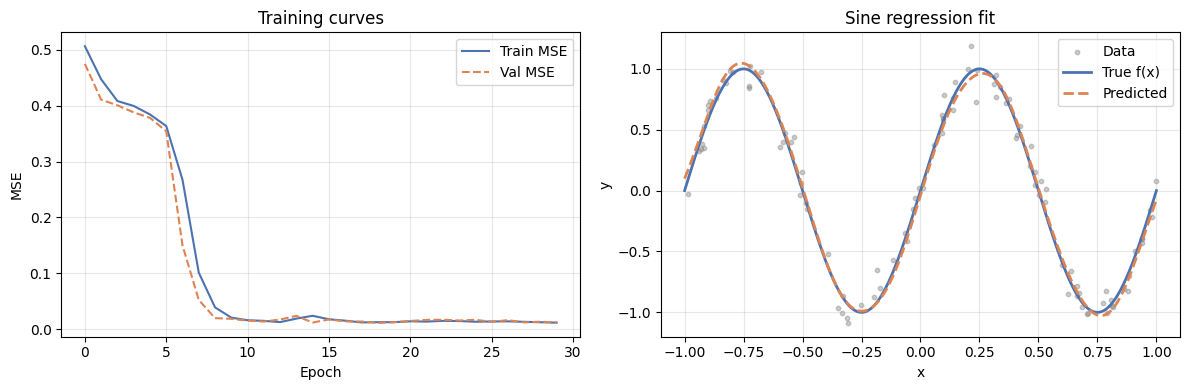


Done! Plot saved to equinox_tutorial.png

BONUS: eqx.filter_jit + shape inference debug tip
Compiled ResNetMLP jaxpr has 116 equations (ops) for batch input (300, 1)


In [4]:
BATCH  = 128
EPOCHS = 30
steps_per_epoch = len(X_train) // BATCH
train_losses, val_losses = [], []

t0 = time.time()
for epoch in range(EPOCHS):
    key, sk = jax.random.split(key)
    perm = jax.random.permutation(sk, len(X_train))
    X_s, Y_s = X_train[perm], Y_train[perm]

    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        xb = X_s[step*BATCH:(step+1)*BATCH]
        yb = Y_s[step*BATCH:(step+1)*BATCH]
        model, opt_state, loss = train_step(model, opt_state, xb, yb)
        epoch_loss += loss.item()

    val_loss = evaluate(model, X_val, Y_val).item()
    train_losses.append(epoch_loss / steps_per_epoch)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  "
              f"train_loss={train_losses[-1]:.5f}  "
              f"val_loss={val_losses[-1]:.5f}")

print(f"\nTotal training time: {time.time()-t0:.1f}s")

print("\n" + "="*60)
print("SECTION 7: Save & load model weights")
print("="*60)

eqx.tree_serialise_leaves("model_weights.eqx", model)

key, mk2 = jax.random.split(key)
model_skeleton = ResNetMLP(1, 64, 1, n_blocks=4, key=mk2)
model_loaded   = eqx.tree_deserialise_leaves("model_weights.eqx", model_skeleton)

diff = jnp.max(jnp.abs(
    jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array))[0]
  - jax.tree_util.tree_leaves(eqx.filter(model_loaded, eqx.is_array))[0]
))
print(f"Max weight difference after reload: {diff:.2e}  (should be 0.0)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train MSE", color="#4C72B0")
axes[0].plot(val_losses,   label="Val MSE",   color="#DD8452", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Training curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

x_plot  = jnp.linspace(-1, 1, 300).reshape(-1, 1)
y_true  = jnp.sin(2 * jnp.pi * x_plot)
y_pred  = jax.vmap(model)(x_plot)

axes[1].scatter(X_val[:100], Y_val[:100], s=10, alpha=0.4, color="gray", label="Data")
axes[1].plot(x_plot, y_true, color="#4C72B0",  linewidth=2, label="True f(x)")
axes[1].plot(x_plot, y_pred, color="#DD8452", linewidth=2, linestyle="--", label="Predicted")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Sine regression fit")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("equinox_tutorial.png", dpi=150)
plt.show()
print("\nDone! Plot saved to equinox_tutorial.png")

print("\n" + "="*60)
print("BONUS: eqx.filter_jit + shape inference debug tip")
print("="*60)

jaxpr = jax.make_jaxpr(jax.vmap(model))(x_plot)
n_eqns = len(jaxpr.jaxpr.eqns)
print(f"Compiled ResNetMLP jaxpr has {n_eqns} equations (ops) for batch input {x_plot.shape}")